# PolySHAP in `shapiq`: reproducing the paper

PolySHAP (Fumagalli et al., *PolySHAP: Extending KernelSHAP with
Interaction-Informed Polynomial Regression*, ICLR 2026) is now a first-class
part of this `shapiq` build, exposed as two Shapley-value approximators:
`PolySHAPKAdd` (full *k*-additive interaction frontier) and `PolySHAPPartial`
(budget-controlled partial frontier).

This notebook reproduces the paper's headline figures **from the integrated
approximators** and places each published panel next to its freshly computed
counterpart. Agreement on both sides serves two purposes at once: it confirms
the integration is faithful to the reference implementation, and it
independently corroborates the paper's empirical claims.

### How the paper's methods map onto the integrated API

| Paper method | Integrated `shapiq` approximator |
|---|---|
| 1-PolySHAP (KernelSHAP) | `PolySHAPKAdd(n, max_order=1)` |
| *k*-PolySHAP (*k* = 2, 3, 4) | `PolySHAPKAdd(n, max_order=k)` |
| 3-PolySHAP (50%) | `PolySHAPPartial(n, n_explanation_terms=1+d+C(d,2)+0.5·C(d,3))` |
| PolySHAP (log) | `PolySHAPPartial(n, n_explanation_terms=1+d+C(d,2)+d·log C(d,3))` |
| Permutation / SVARM / MSR | `PermutationSamplingSV` / `SVARM` / `UnbiasedKernelSHAP` |

### Data and ground truth

The image and language games of the paper's Table 2 (ViT9 *d*=9,
ResNet18 *d*=14, ViT16 *d*=16, DistilBERT *d*=14) ship as **exhaustive game
tables** — every coalition value is stored. Exact Shapley ground truth is
therefore obtained directly with `shapiq.ExactComputer`; no model inference is
needed and the reference implementation is never imported.

## 0 · Setup

Expensive sweeps are written to `cache/` and reloaded on re-run; figures are
regenerated into `plots/` every time.

In [1]:
import sys
from pathlib import Path

# paper_repro.py lives next to this notebook; make it importable.
HERE = Path.cwd()
for cand in (HERE, HERE / "polyshap", HERE / "notebooks" / "polyshap"):
    if (cand / "paper_repro.py").exists():
        sys.path.insert(0, str(cand))
        NB_DIR = cand
        break
else:
    raise FileNotFoundError("paper_repro.py not found next to the notebook")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import paper_repro as R
from paper_repro import (
    DEFAULT_DATA_ROOT as DATA_ROOT,
    GAME_SPECS, HIGHER_ORDER, COLORS, AXIS_SPECS,
    cached_run_sweep, _agg, load_game, exact_shapley, make_method, compute_metrics,
)

ASSETS = NB_DIR / "assets"
CACHE_DIR = NB_DIR / "cache"
PLOTS_DIR = NB_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    # always overwrite the figure under plots/
    path = PLOTS_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

print("integrated shapiq:", __import__("shapiq").__file__)
print("data root:", DATA_ROOT, "| exists:", Path(DATA_ROOT).exists())
print("cache:", CACHE_DIR, "| plots:", PLOTS_DIR)

integrated shapiq: C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PROJECT\shapiq\src\shapiq\__init__.py
data root: C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PolySHAP\data\precomputed_games | exists: True
cache: C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PROJECT\shapiq\notebooks\polyshap\cache | plots: C:\Users\Black\Documents\Studium\SoSe26\TTML Toolbox for Trustworthy Machine Learning\PROJECT\shapiq\notebooks\polyshap\plots


## Hyperparameters

`N_INSTANCES` is the number of explanation games averaged per point (each curve
is the mean ± SEM over these instances). **The paper uses 30**; we keep it small
here so the sweep runs quickly on a laptop. Because the standard error of the
mean scales as 1/√N, a smaller `N_INSTANCES` gives proportionally **wider error
bands** than the paper — this is the main reason our shaded bands look larger.
Raise `N_INSTANCES` toward `PAPER_INSTANCES` to reproduce the paper's tightness
(the result is cached afterwards).

In [2]:
import math

N_INSTANCES = 5       # instances averaged here (small = fast on a laptop)
PAPER_INSTANCES = 30  # the value used in the paper, for reference

sem_factor = math.sqrt(PAPER_INSTANCES / N_INSTANCES)
print(f"Averaging N_INSTANCES={N_INSTANCES} instances per game "
      f"(paper uses {PAPER_INSTANCES}).")
print(f"=> with SEM ∝ 1/sqrt(N), our error bands are ~{sem_factor:.1f}x wider "
      f"than the paper's. Raise N_INSTANCES toward {PAPER_INSTANCES} to match.")

Averaging N_INSTANCES=5 instances per game (paper uses 30).
=> with SEM ∝ 1/sqrt(N), our error bands are ~2.4x wider than the paper's. Raise N_INSTANCES toward 30 to match.


### Plot layout

Constants for fine-tuning the side-by-side panel sizes. They affect rendering
only (not the cached data), so tweak and re-run the figure cells freely:

| Constant | Controls |
|---|---|
| `FIGURE_WIDTH`, `FIGURE_HEIGHT` | total figure size (inches); `FIGURE_HEIGHT` drives the **paper** panel size |
| `PAPER_PANEL_WIDTH`, `SHAPIQ_PANEL_WIDTH` | relative widths of the paper vs. shapiq panels |
| `SHAPIQ_PANEL_HEIGHT_FRACTION` | fraction of the row height the **shapiq** plot uses (smaller ⇒ more compact) |
| `PANEL_HORIZONTAL_GAP` | horizontal gap between the two panels |

In [3]:
FIGURE_WIDTH = 15.0                  # total figure width (inches)
FIGURE_HEIGHT = 6.8                  # total figure height (inches) -> paper-panel size
PAPER_PANEL_WIDTH = 1.2              # relative width of the paper (left) panel
SHAPIQ_PANEL_WIDTH = 1.0             # relative width of the shapiq (right) panel
SHAPIQ_PANEL_HEIGHT_FRACTION = 0.70  # shapiq plot height as a fraction of the row (smaller = more compact)
PANEL_HORIZONTAL_GAP = 0.16          # horizontal gap between the two panels

## 1 · Sanity check

On a single ResNet18 explanation game, the integrated approximators should track
the exact Shapley values closely: perfect top-5 ranking (Precision@5 = 1.0), high
Spearman correlation, and small MSE across orders.

In [4]:
spec = GAME_SPECS["ResNet18"]
game, n = load_game(DATA_ROOT / spec.subdir / spec.pattern.format(i=1))
exact = exact_shapley(game, n)

rows = []
for m in ["1-PolySHAP", "2-PolySHAP", "3-PolySHAP"]:
    iv = make_method(m, n, random_state=0, paired=False).approximate(budget=1000, game=game)
    est = np.asarray(iv.get_n_order_values(1))
    rows.append({"method": m, **compute_metrics(est, exact)})

pd.DataFrame(rows).set_index("method")

,MSE,MAE,Precision@5,Spearman
method,,,,
1-PolySHAP,0.000202,0.011485,1.0,0.942857
2-PolySHAP,0.000159,0.010657,1.0,0.951648
3-PolySHAP,0.000169,0.010974,1.0,0.929670


## 2 · Plotting helpers

`shapiq_panel` draws one game's MSE-vs-budget curves (mean ± SEM across instances)
with the **paper's colour per algorithm** and the **same axes as the paper**:
a linear budget axis and a logarithmic MSE axis on identical limits. Standard
sampling is dashed, paired sampling is solid. At the full-enumeration budget
(2^d) the estimate is exact, so MSE collapses to ~machine zero; that point is
clamped to the axis floor so the curves converge at the right edge — matching
the paper's rightmost (100%-budget) point — rather than plunging off-scale.
Each panel title shows `N`, the number of instances averaged.

In [5]:
DASH = {"standard": ("--", "o"), "paired": ("-", "s")}

def shapiq_panel(ax, df, game, methods, samplings=("standard",), styles=DASH):
    agg = _agg(df, "MSE")
    spec = AXIS_SPECS[game]
    floor = spec["ylim"][0]
    sub = agg[agg["game"] == game]
    for m in methods:
        for samp in samplings:
            s = sub[(sub["method"] == m) & (sub["sampling"] == samp)].sort_values("budget")
            if s.empty:
                continue
            ls, mk = styles[samp]
            # At the full-enumeration budget (2**d) the estimate is exact, so MSE
            # collapses to ~machine zero. Clamp to the axis floor so the curves
            # converge there — as the paper's rightmost (100%-budget) point does —
            # instead of plunging off-scale.
            mean = np.maximum(s["mean"].to_numpy(), floor)
            lo = np.maximum((s["mean"] - s["sem"]).to_numpy(), floor)
            hi = np.maximum((s["mean"] + s["sem"]).to_numpy(), floor)
            ax.plot(s["budget"], mean, ls=ls, marker=mk, ms=4, lw=1.6, color=COLORS[m])
            ax.fill_between(s["budget"], lo, hi, color=COLORS[m], alpha=0.18, lw=0)
    x0, x1 = spec["xlim"]
    pad = 0.03 * (x1 - x0)  # start slightly left of 0 so x=0 points clear the y-axis
    ax.set_yscale("log")
    ax.set_xlim(x0 - pad, x1)
    ax.set_xticks(spec["xticks"])
    ax.set_ylim(*spec["ylim"])
    ax.set_xlabel("Budget (m)")
    ax.set_ylabel("MSE ± SEM")
    ax.set_title(f"{game} (d={GAME_SPECS[game].d}) — shapiq implementation (N={N_INSTANCES})")
    # vertical gridlines only (at the budget ticks), matching the paper
    ax.grid(True, axis="x", which="major", ls=":", alpha=0.4)
    ax.grid(False, axis="y")

def show_image(ax, fname, title=None):
    ax.imshow(plt.imread(str(ASSETS / fname)))
    ax.axis("off")
    if title:
        ax.set_title(title)

def side_by_side(paper_png, df, game, methods, samplings=("standard",), save_as=None):
    # Paper panel ~2x larger; wider left column + taller figure so the image
    # (fixed aspect) fills more of its axis. No tight_layout: it is incompatible
    # with the fixed-aspect imshow axis and emits a warning.
    fig = plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    gs = gridspec.GridSpec(1, 2, width_ratios=[PAPER_PANEL_WIDTH, SHAPIQ_PANEL_WIDTH],
                           wspace=PANEL_HORIZONTAL_GAP)
    show_image(fig.add_subplot(gs[0]), paper_png, f"{game} — PolySHAP paper (N={PAPER_INSTANCES})")
    # nest the shapiq axes in a shorter, vertically-centred slot so the plot is
    # more compact (landscape) while the paper panel keeps its full height
    pad = max((1.0 - SHAPIQ_PANEL_HEIGHT_FRACTION) / 2.0, 1e-3)
    gs_r = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[1],
                                            height_ratios=[pad, SHAPIQ_PANEL_HEIGHT_FRACTION, pad])
    shapiq_panel(fig.add_subplot(gs_r[1]), df, game, methods, samplings)
    if save_as:
        save_fig(fig, save_as)
    plt.show()

def show_legend(fname, save_as):
    fig, ax = plt.subplots(figsize=(13, 1.2))
    show_image(ax, fname)
    save_fig(fig, save_as)
    plt.show()

## 3 · Figure 2 — higher-order interactions improve approximation quality

The paper's central result: under a fixed evaluation budget, adding
higher-order interaction terms lowers the Shapley-value estimation error, so
3-PolySHAP < 2-PolySHAP < 1-PolySHAP (KernelSHAP) in MSE. The panels below
reproduce this on ResNet18 and ViT16 — the two games that also appear in the
paper's Figure 2 — with the legend shown once and shared across all panels.

In [6]:
# Full k-additive frontiers (1..4) plus the two partial "50%" frontiers shown in
# the paper's Figure 2 (2-/3-PolySHAP at 50% of their top-order interactions).
FIG2_METHODS = HIGHER_ORDER + ["2-PolySHAP(50%)", "3-PolySHAP(50%)"]

df2 = cached_run_sweep(DATA_ROOT, ["ResNet18", "ViT16"], N_INSTANCES,
                       FIG2_METHODS, sampling_modes=[False], seed=40, cache_dir=CACHE_DIR)
print(f"{(df2['status'] == 'ok').sum()} ok cells / {len(df2)}")

[cache hit ] sweep_bd7bb6ca7f.csv
390 ok cells / 600


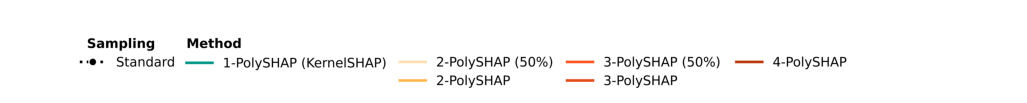

In [7]:
# Shared legend (paper colours), rendered once.
show_legend("paper_fig2_legend.png", "fig2_legend.png")

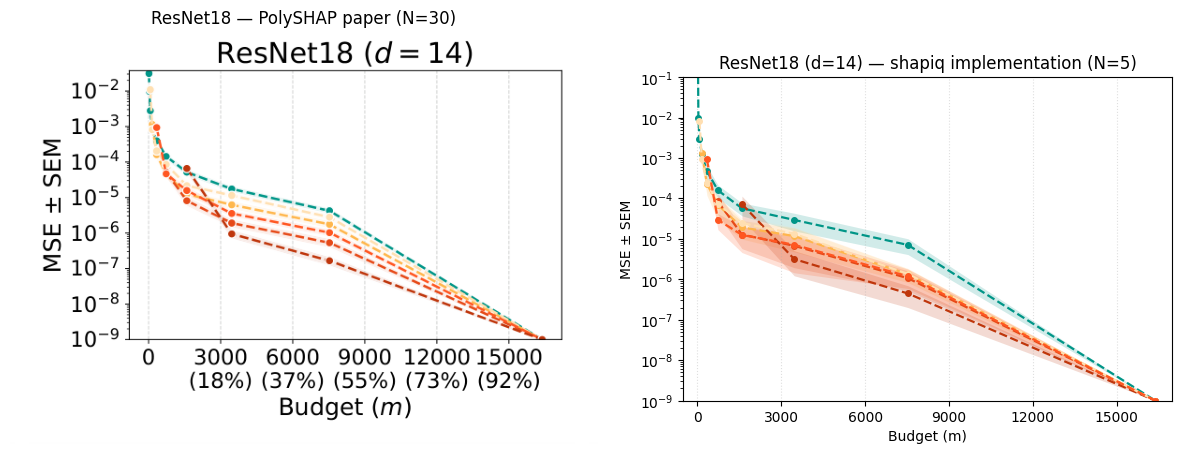

In [8]:
side_by_side("paper_fig2_ResNet18.png", df2, "ResNet18", FIG2_METHODS, save_as="fig2_ResNet18.png")

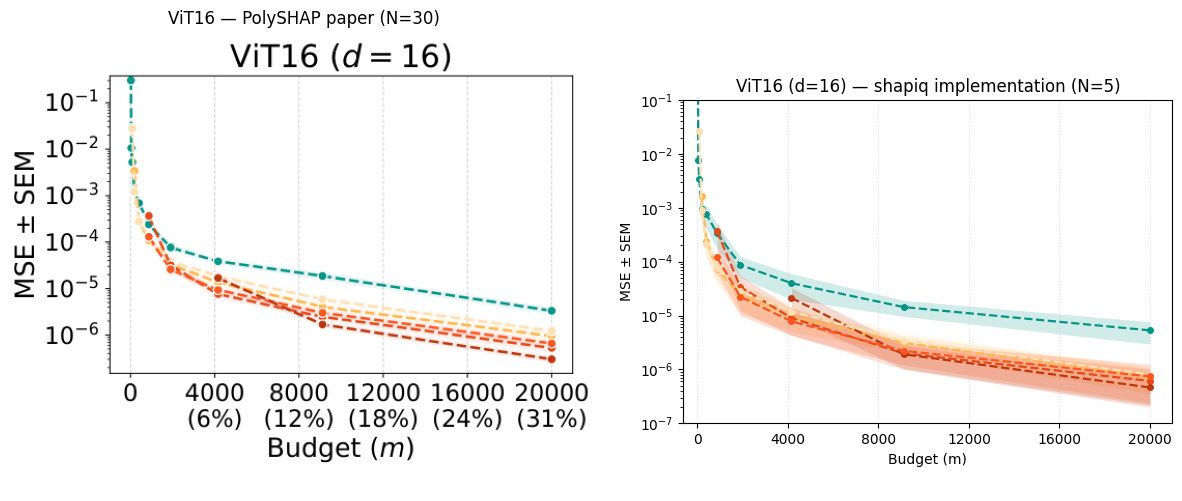

In [9]:
side_by_side("paper_fig2_ViT16.png", df2, "ViT16", FIG2_METHODS, save_as="fig2_ViT16.png")

The ordering is confirmed numerically below: at the largest sub-exhaustive
budget, mean MSE decreases monotonically with interaction order on both games.

In [10]:
ok = df2[df2["status"] == "ok"].copy()
ok = ok[ok["budget"] < 2 ** ok["d"]]
ref = ok.groupby("game")["budget"].max()
ref_rows = ok[ok.apply(lambda r: r["budget"] == ref[r["game"]], axis=1)]
table = ref_rows.pivot_table(index="method", columns="game", values="MSE", aggfunc="mean")
table = table.reindex([m for m in HIGHER_ORDER if m in table.index])
print("reference budget per game:", {g: int(b) for g, b in ref.items()})
table

reference budget per game: {'ResNet18': 7531, 'ViT16': 20000}


game,ResNet18,ViT16
method,,
1-PolySHAP,7.095800e-06,5.306468e-06
2-PolySHAP,1.335137e-06,7.170008e-07
3-PolySHAP,1.067180e-06,6.110718e-07
4-PolySHAP,4.472139e-07,4.633577e-07


## 4 · Figure 3 — paired KernelSHAP behaves like 2-PolySHAP

A further result of the paper (Theorem 5.1) is that KernelSHAP with paired
(antithetic) sampling returns the same estimates as 2-PolySHAP. With paired
sampling (solid) the 1-PolySHAP curve drops onto the 2-PolySHAP curve, whereas
under standard sampling (dashed) 1-PolySHAP stays clearly above it. The paper
reports the analogous collapse one order up — paired 3-PolySHAP ≈ 4-PolySHAP —
so all four orders are shown here (the effect is noisier at the small
`N_INSTANCES` used for speed).

**Why the orders collapse.** Paired sampling draws every coalition *S* together
with its complement *N∖S*. The even-degree interaction terms of the polynomial
are symmetric under that swap, so averaging a coalition with its complement
captures them *for free*: a degree-*k* fit then yields the same Shapley values as
an explicit degree-*(k+1)* fit, for odd *k*. That upgrades 1→2 and 3→4 (an even
order is the freebie), which is why the curves overlap in pairs under pairing
while staying ordered by degree under standard sampling. Practically, paired
KernelSHAP — the cheapest estimator — gains 2-PolySHAP's accuracy at no extra
cost, explaining the long-known effectiveness of antithetic sampling.

In [11]:
FIG3_METHODS = ["1-PolySHAP", "2-PolySHAP", "3-PolySHAP", "4-PolySHAP"]
df3 = cached_run_sweep(DATA_ROOT, ["ResNet18", "ViT16"], N_INSTANCES,
                       FIG3_METHODS, sampling_modes=[False, True],
                       seed=40, cache_dir=CACHE_DIR)
print(f"{(df3['status'] == 'ok').sum()} ok cells / {len(df3)}")

[cache hit ] sweep_0f28753e67.csv
510 ok cells / 800


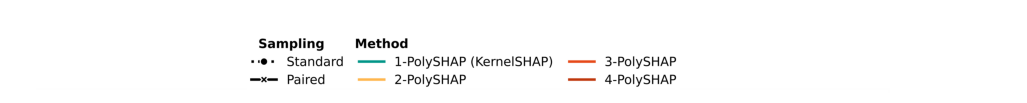

In [12]:
show_legend("paper_fig3_legend.png", "fig3_legend.png")

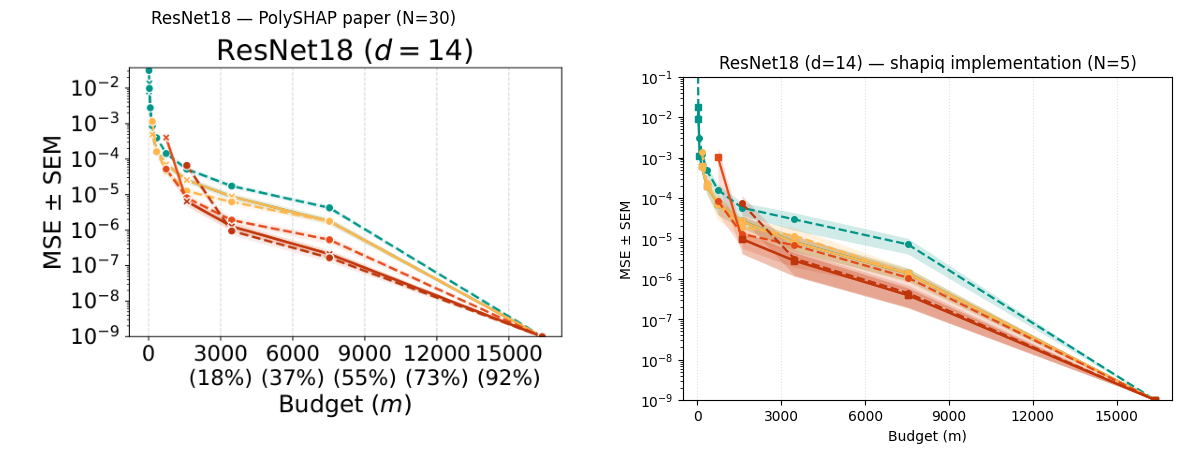

In [13]:
side_by_side("paper_fig3_ResNet18.png", df3, "ResNet18",
             FIG3_METHODS, samplings=("standard", "paired"), save_as="fig3_ResNet18.png")

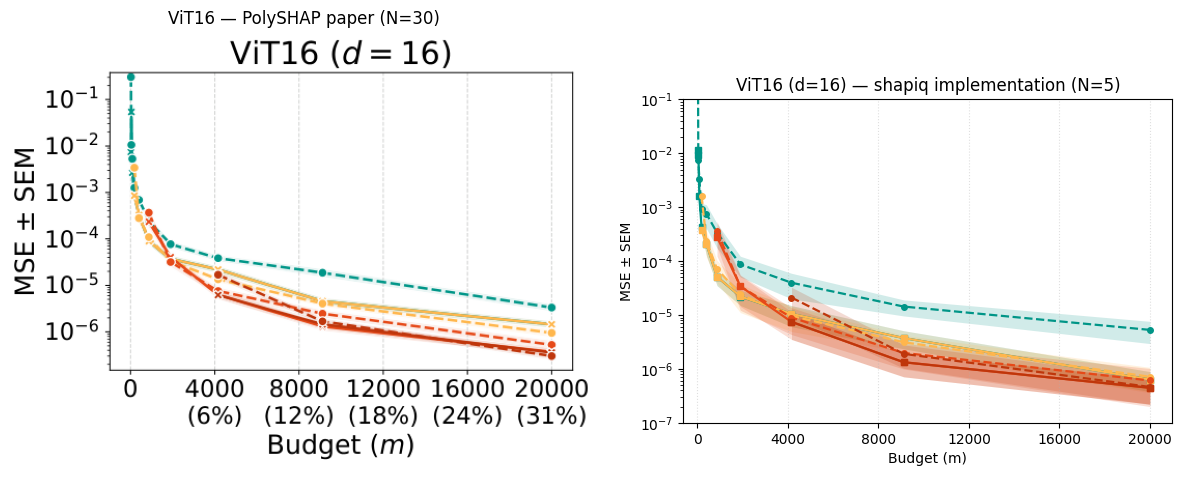

In [14]:
side_by_side("paper_fig3_ViT16.png", df3, "ViT16",
             FIG3_METHODS, samplings=("standard", "paired"), save_as="fig3_ViT16.png")

## Conclusion

On both ResNet18 and ViT16 the integrated approximators reproduce the paper's
behaviour: MSE falls with interaction order (Figure 2), and paired KernelSHAP
collapses onto 2-PolySHAP (Figure 3). The `PolySHAPKAdd` and `PolySHAPPartial`
approximators are therefore a faithful, fully integrated implementation of
PolySHAP in `shapiq`, and the paper's empirical claims hold on these games.

All sweep results are cached under `cache/`; all panels are saved under
`plots/`. Increasing `INSTANCES` tightens the error bands (the paper averages
over 30 instances).